In [11]:
!pip install datasets huggingface_hub

In [12]:
import random
from datasets import load_dataset, DatasetDict
from huggingface_hub import login
from google.colab import userdata

In [13]:
HF_TOKEN = userdata.get("HF_TOKEN")
if HF_TOKEN:
    login(token=HF_TOKEN)
    print("Logged in using environment variable")
else:
    print("No HF_TOKEN found")

Logged in using environment variable


In [14]:
# Load Dataset
dataset = load_dataset("Lakshan2003/customer-support-client-agent-conversations")

In [15]:
# Get train split
train_data = dataset["train"]

# Randomly Select 50k Samples
train_data = train_data.shuffle(seed=42)
subset_50k = train_data.select(range(50000))

# Train / Validation / Test Split
#    70 / 10 / 20

# split off 20% test
split_1 = subset_50k.train_test_split(test_size=0.2, seed=42)
train_val = split_1["train"]   # 80%
test_split = split_1["test"]   # 20%

# From remaining 80%, take 12.5% as validation
# (12.5% of 80% = 10% of total)
split_2 = train_val.train_test_split(test_size=0.125, seed=42)
train_split = split_2["train"]        # 70%
validation_split = split_2["test"]    # 10%

print("Train size:", len(train_split))        # 35,000
print("Validation size:", len(validation_split))  # 5,000
print("Test size:", len(test_split))          # 10,000

Train size: 35000
Validation size: 5000
Test size: 10000


In [16]:
PROMPT_TEMPLATE = """You are a professional conversation summarization assistant.
Goal:
Produce a clear, concise and factual summary of the conversation so far so that
YOU, the same customer service agent handling this client, can accurately answer
their next question.
Include only information explicitly stated:
- Client’s issue or request and current status (explicitly mention client and
agent names if present in the conversation)
- Verification steps completed or pending
- Exact names, account numbers or identifiers, dates, amounts and actions taken
or agreed
- Commitments, deadlines and follow-up actions
- Current state of the conversation
Exclude:
Greetings, filler dialogue, speculation, assumptions, or invented details.
Style:
Neutral and professional. Vary sentence structure and phrasing to avoid repetition.
Output:
One coherent, detailed paragraph summarizing the conversation context.
"""

def add_prompt(batch):
    batch["summarization_prompt"] = [PROMPT_TEMPLATE] * len(batch["conversation_history"])
    return batch

train_split = train_split.map(add_prompt, batched=True)
validation_split = validation_split.map(add_prompt, batched=True)
test_split = test_split.map(add_prompt, batched=True)

Map:   0%|          | 0/35000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [17]:
# Desired column order
new_order = [
    "conversation_id",
    "instruction",
    "conversation_history",
    "summarization_prompt",   # <-- BEFORE history_summary
    "history_summary",
    "client_question",
    "agent_answer",
    "refined_agent_answer"
]

train_split = train_split.select_columns(new_order)
validation_split = validation_split.select_columns(new_order)
test_split = test_split.select_columns(new_order)

In [18]:
train_split[0]

{'conversation_id': '3f12fc90a0614b58917735a2fb23f952',
 'instruction': 'You are a professional call-center customer service agent working at **Valley Financial Partners**.\nReview the conversation history and any provided context (if available).\nMake sure your response is consistent with the conversation history (names, issues, and actions already taken).\nIf no history is given, treat the client’s message as the start of the conversation.\nContinue the dialogue as the agent by giving a clear, helpful, and professional response.\nResponses should sound natural and human-like, like a real phone call, and usually be few short sentences.\nProvide more detail when the client’s request clearly requires it.',
 'conversation_history': "Agent: Hello morning, thank you for calling Valley Financial Partners. My name is Timmy, how may I assist you today?\nClient: Hi Timmy, my name is Robert. I need a question regarding tax forms and documentation. Who should I speak with?\nAgent: Good Robert, I

In [19]:
new_dataset = DatasetDict({
    "train": train_split,
    "validation": validation_split,
    "test": test_split
})


new_dataset.push_to_hub("Lakshan2003/customer-support-context-summary-100k")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/35 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  80%|########  | 32.5MB / 40.5MB            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  96%|#########6| 11.1MB / 11.5MB            

README.md:   0%|          | 0.00/828 [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/datasets/Lakshan2003/customer-support-context-summary-100k/commit/0935da7fdd2f2dcd7a5f87474b7ddd406fc7d748', commit_message='Upload dataset', commit_description='', oid='0935da7fdd2f2dcd7a5f87474b7ddd406fc7d748', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/Lakshan2003/customer-support-context-summary-100k', endpoint='https://huggingface.co', repo_type='dataset', repo_id='Lakshan2003/customer-support-context-summary-100k'), pr_revision=None, pr_num=None)


========== conversation_history ==========
Count: 50000
Mean: 269.48
Median: 259.00
Std: 150.88
Min: 0
Max: 2074
90th Percentile: 457.00
95th Percentile: 527.00
99th Percentile: 698.02

========== summarization_prompt ==========
Count: 50000
Mean: 165.00
Median: 165.00
Std: 0.00
Min: 165
Max: 165
90th Percentile: 165.00
95th Percentile: 165.00
99th Percentile: 165.00

========== history_summary ==========
Count: 50000
Mean: 111.74
Median: 113.00
Std: 35.30
Min: 0
Max: 257
90th Percentile: 156.00
95th Percentile: 169.00
99th Percentile: 195.00

========== input_total ==========
Count: 50000
Mean: 434.48
Median: 424.00
Std: 150.88
Min: 165
Max: 2239
90th Percentile: 622.00
95th Percentile: 692.00
99th Percentile: 863.02


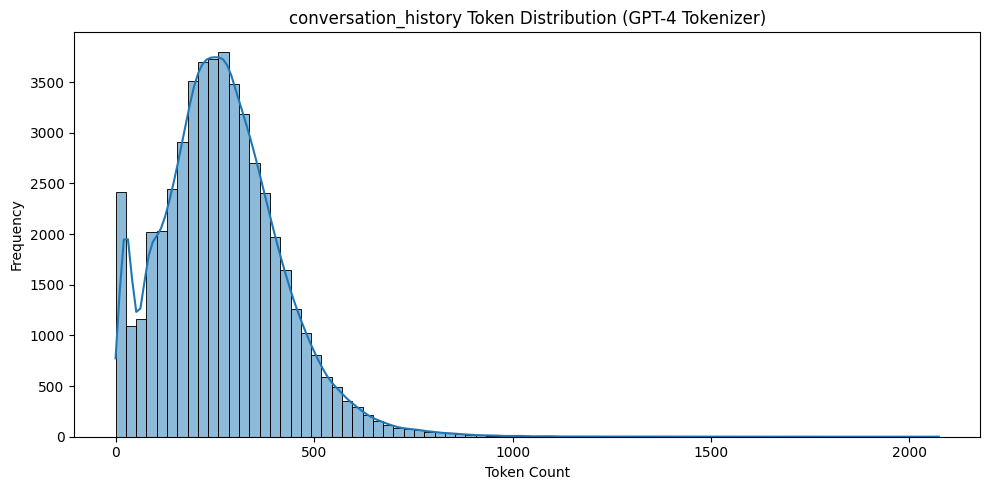

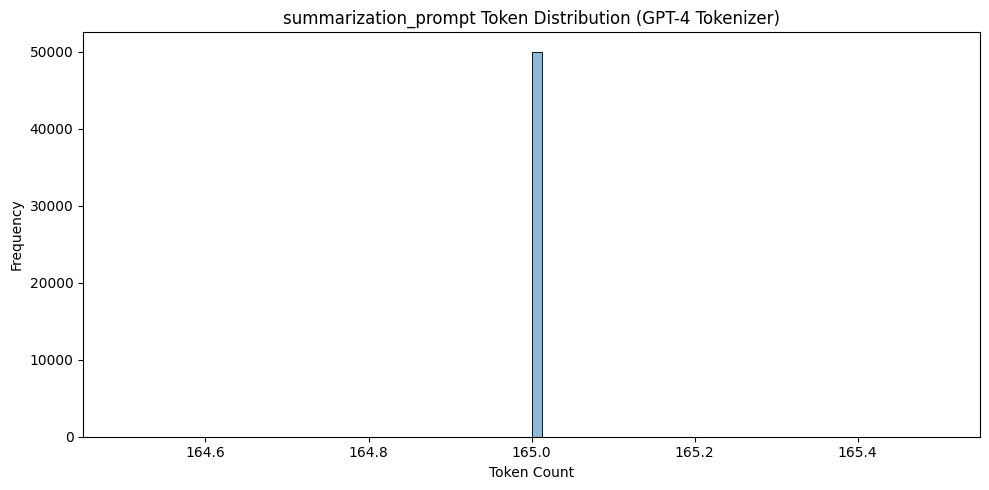

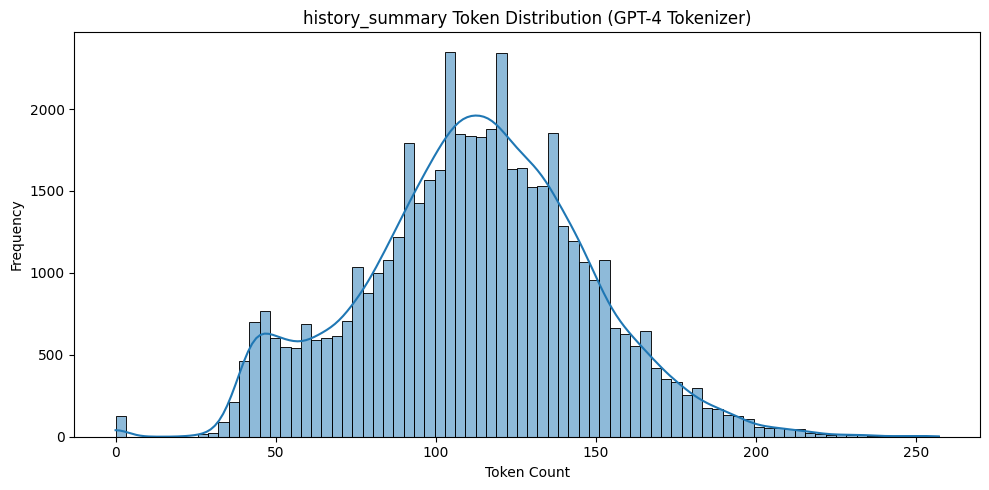

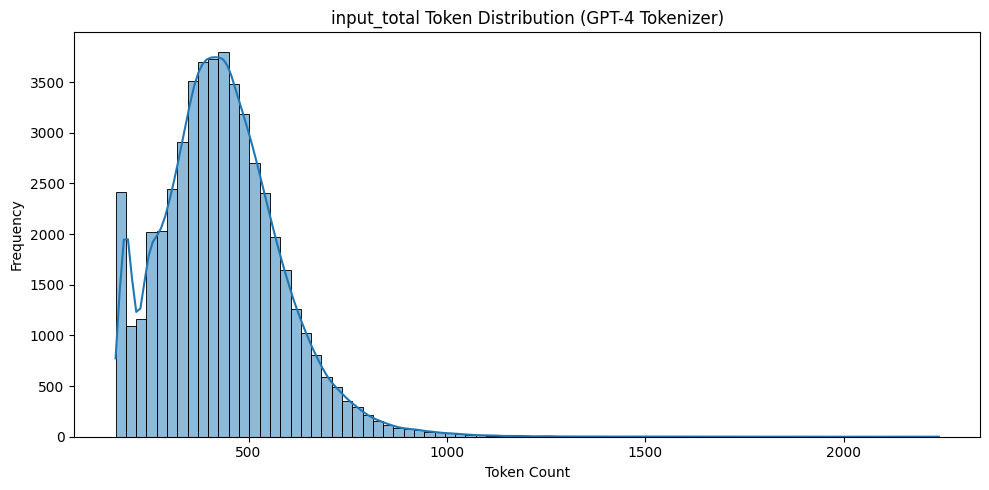

In [20]:
import tiktoken
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import concatenate_datasets

# GPT-4 Tokenizer
encoding = tiktoken.get_encoding("cl100k_base")

def count_tokens(text):
    if text is None:
        return 0
    return len(encoding.encode(text))

# Combine Splits
full_dataset = concatenate_datasets([
    train_split,
    validation_split,
    test_split
])

# Compute Token Counts
conversation_tokens = []
prompt_tokens = []
summary_tokens = []

for example in full_dataset:
    conversation_tokens.append(count_tokens(example["conversation_history"]))
    prompt_tokens.append(count_tokens(example["summarization_prompt"]))
    summary_tokens.append(count_tokens(example["history_summary"]))

df = pd.DataFrame({
    "conversation_history": conversation_tokens,
    "summarization_prompt": prompt_tokens,
    "history_summary": summary_tokens
})

# Combined input (Prompt + Conversation)
df["input_total"] = df["conversation_history"] + df["summarization_prompt"]

# Detailed Statistics
def print_stats(series, name):
    print(f"\n========== {name} ==========")
    print(f"Count: {len(series)}")
    print(f"Mean: {series.mean():.2f}")
    print(f"Median: {series.median():.2f}")
    print(f"Std: {series.std():.2f}")
    print(f"Min: {series.min()}")
    print(f"Max: {series.max()}")
    print(f"90th Percentile: {series.quantile(0.90):.2f}")
    print(f"95th Percentile: {series.quantile(0.95):.2f}")
    print(f"99th Percentile: {series.quantile(0.99):.2f}")

for column in df.columns:
    print_stats(df[column], column)

# Separate Histogram + KDE Plots
for column in df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[column], bins=80, kde=True)
    plt.title(f"{column} Token Distribution (GPT-4 Tokenizer)")
    plt.xlabel("Token Count")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()